In [1]:
#IMPORTING RELEVANT LIBRARIES

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import asarray 
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
evision = pd.read_csv('ElectricCarData_Clean.csv')

# datacleaning
evision['FastCharge_KmH'] = evision['FastCharge_KmH'].str.replace('-', '0').astype(int)
evision['RapidCharge'] = evision['RapidCharge'].map({'Yes':1, 'No':0})

# feature engineering
evision['Battery_kWh'] = (evision['Range_Km'] * evision['Efficiency_WhKm']) / 1000
evision['PerformanceIndex'] = evision['TopSpeed_KmH'] / evision['AccelSec']
evision['PricePerKm'] = evision['PriceEuro'] / evision['Range_Km']
evision.head()

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro,Battery_kWh,PerformanceIndex,PricePerKm
0,Tesla,Model 3 Long Range Dual Motor,4.6,233,450,161,940,1,AWD,Type 2 CCS,Sedan,D,5,55480,72.45,50.652174,123.288889
1,Volkswagen,ID.3 Pure,10.0,160,270,167,250,1,RWD,Type 2 CCS,Hatchback,C,5,30000,45.09,16.000000,111.111111
2,Polestar,2,4.7,210,400,181,620,1,AWD,Type 2 CCS,Liftback,D,5,56440,72.40,44.680851,141.100000
3,BMW,iX3,6.8,180,360,206,560,1,RWD,Type 2 CCS,SUV,D,5,68040,74.16,26.470588,189.000000
4,Honda,e,9.5,145,170,168,190,1,RWD,Type 2 CCS,Hatchback,B,4,32997,28.56,15.263158,194.100000


In [2]:
evision.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             103 non-null    object 
 1   Model             103 non-null    object 
 2   AccelSec          103 non-null    float64
 3   TopSpeed_KmH      103 non-null    int64  
 4   Range_Km          103 non-null    int64  
 5   Efficiency_WhKm   103 non-null    int64  
 6   FastCharge_KmH    103 non-null    int32  
 7   RapidCharge       103 non-null    int64  
 8   PowerTrain        103 non-null    object 
 9   PlugType          103 non-null    object 
 10  BodyStyle         103 non-null    object 
 11  Segment           103 non-null    object 
 12  Seats             103 non-null    int64  
 13  PriceEuro         103 non-null    int64  
 14  Battery_kWh       103 non-null    float64
 15  PerformanceIndex  103 non-null    float64
 16  PricePerKm        103 non-null    float64
dt

In [3]:
# Identifying all categorical columns in the dataset
object_column = evision.select_dtypes(include ='object')
object_column.head()

,Brand,Model,PowerTrain,PlugType,BodyStyle,Segment
0,Tesla,Model 3 Long Range Dual Motor,AWD,Type 2 CCS,Sedan,D
1,Volkswagen,ID.3 Pure,RWD,Type 2 CCS,Hatchback,C
2,Polestar,2,AWD,Type 2 CCS,Liftback,D
3,BMW,iX3,RWD,Type 2 CCS,SUV,D
4,Honda,e,RWD,Type 2 CCS,Hatchback,B


In [4]:
#Ecoding categorical columns

ev1 = evision[['Brand', 'Model', 'RapidCharge', 'PlugType', 'BodyStyle', 'Segment', 'PowerTrain']]
print(ev1)

#define ordinal encoding
encoder = OrdinalEncoder()

#transform data
result = encoder.fit_transform(ev1)
print(result)

           Brand                            Model  RapidCharge    PlugType  \
0         Tesla     Model 3 Long Range Dual Motor            1  Type 2 CCS   
1    Volkswagen                         ID.3 Pure            1  Type 2 CCS   
2      Polestar                                 2            1  Type 2 CCS   
3           BMW                              iX3             1  Type 2 CCS   
4         Honda                                e             1  Type 2 CCS   
..           ...                              ...          ...         ...   
98       Nissan                       Ariya 63kWh            1  Type 2 CCS   
99         Audi     e-tron S Sportback 55 quattro            1  Type 2 CCS   
100      Nissan               Ariya e-4ORCE 63kWh            1  Type 2 CCS   
101      Nissan   Ariya e-4ORCE 87kWh Performance            1  Type 2 CCS   
102       Byton                 M-Byte 95 kWh 2WD            1  Type 2 CCS   

     BodyStyle Segment PowerTrain  
0        Sedan       D     

In [5]:
temp =['Brand', 'Model', 'RapidCharge', 'PlugType', 'BodyStyle', 'Segment', 'PowerTrain']
evision.drop(temp, axis=1, inplace = True)
result = pd.DataFrame(result)

In [6]:
result.columns= ['Brand', 'Model', 'RapidCharge', 'PlugType', 'BodyStyle', 'Segment', 'PowerTrain']
result.index+=1

In [7]:
result

,Brand,Model,RapidCharge,PlugType,BodyStyle,Segment,PowerTrain
1,30.0,46.0,1.0,2.0,7.0,3.0,0.0
2,31.0,33.0,1.0,2.0,1.0,2.0,2.0
3,23.0,0.0,1.0,2.0,2.0,3.0,0.0
4,2.0,101.0,1.0,2.0,6.0,3.0,2.0
5,9.0,78.0,1.0,2.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...
99,20.0,6.0,1.0,2.0,1.0,2.0,1.0
100,1.0,94.0,1.0,2.0,6.0,4.0,0.0
101,20.0,8.0,1.0,2.0,1.0,2.0,0.0
102,20.0,10.0,1.0,2.0,1.0,2.0,0.0


In [8]:
ev1 =evision
ev1.index+=1

In [9]:
ev1[['Brand', 'Model', 'RapidCharge', 'PlugType', 'BodyStyle', 'Segment', 'PowerTrain']] = result[['Brand', 'Model', 'RapidCharge', 'PlugType', 'BodyStyle', 'Segment', 'PowerTrain']]
evision

,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,Seats,PriceEuro,Battery_kWh,PerformanceIndex,PricePerKm,Brand,Model,RapidCharge,PlugType,BodyStyle,Segment,PowerTrain
1,4.6,233,450,161,940,5,55480,72.45,50.652174,123.288889,30.0,46.0,1.0,2.0,7.0,3.0,0.0
2,10.0,160,270,167,250,5,30000,45.09,16.000000,111.111111,31.0,33.0,1.0,2.0,1.0,2.0,2.0
3,4.7,210,400,181,620,5,56440,72.40,44.680851,141.100000,23.0,0.0,1.0,2.0,2.0,3.0,0.0
4,6.8,180,360,206,560,5,68040,74.16,26.470588,189.000000,2.0,101.0,1.0,2.0,6.0,3.0,2.0
5,9.5,145,170,168,190,4,32997,28.56,15.263158,194.100000,9.0,78.0,1.0,2.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,7.5,160,330,191,440,5,45000,63.03,21.333333,136.363636,20.0,6.0,1.0,2.0,1.0,2.0,1.0
100,4.5,210,335,258,540,5,96050,86.43,46.666667,286.716418,1.0,94.0,1.0,2.0,6.0,4.0,0.0
101,5.9,200,325,194,440,5,50000,63.05,33.898305,153.846154,20.0,8.0,1.0,2.0,1.0,2.0,0.0
102,5.1,200,375,232,450,5,65000,87.00,39.215686,173.333333,20.0,10.0,1.0,2.0,1.0,2.0,0.0


In [10]:
#check the correlation between different features
evision.corr()

,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,Seats,PriceEuro,Battery_kWh,PerformanceIndex,PricePerKm,Brand,Model,RapidCharge,PlugType,BodyStyle,Segment,PowerTrain
AccelSec,1.000000,-0.786195,-0.677062,-0.382904,-0.782324,-0.175335,-0.627174,-0.683769,-0.729737,-0.248267,0.062730,-0.050635,-0.514820,-0.259657,-0.347164,-0.451568,0.521011
TopSpeed_KmH,-0.786195,1.000000,0.746662,0.355675,0.778422,0.126470,0.829057,0.731267,0.955230,0.434586,0.101759,0.067814,0.251054,-0.010110,0.339230,0.670403,-0.560538
Range_Km,-0.677062,0.746662,1.000000,0.313077,0.750859,0.300163,0.674844,0.921382,0.743215,0.005490,0.088316,-0.066035,0.401290,0.131297,0.227477,0.628597,-0.451495
Efficiency_WhKm,-0.382904,0.355675,0.313077,1.000000,0.319678,0.301230,0.396705,0.634144,0.313389,0.354055,-0.195901,0.010976,0.105673,-0.028761,0.373146,0.623263,-0.394721
FastCharge_KmH,-0.782324,0.778422,0.750859,0.319678,1.000000,0.262732,0.658882,0.702178,0.687318,0.217702,0.094678,0.036194,0.449047,0.209947,0.414552,0.606983,-0.481724
Seats,-0.175335,0.126470,0.300163,0.301230,0.262732,1.000000,0.020920,0.333926,0.063918,-0.250898,0.089589,-0.018943,0.423111,-0.029570,0.342489,0.416744,-0.278882
PriceEuro,-0.627174,0.829057,0.674844,0.396705,0.658882,0.020920,1.000000,0.664907,0.835761,0.716711,-0.036023,0.169003,0.197208,-0.000193,0.321713,0.737106,-0.561584
Battery_kWh,-0.683769,0.731267,0.921382,0.634144,0.702178,0.333926,0.664907,1.000000,0.728325,0.109433,0.029568,-0.069167,0.341906,0.091664,0.282913,0.718508,-0.490959
PerformanceIndex,-0.729737,0.955230,0.743215,0.313389,0.687318,0.063918,0.835761,0.728325,1.000000,0.440185,0.165632,0.053333,0.190856,-0.060067,0.219523,0.632560,-0.517279
PricePerKm,-0.248267,0.434586,0.005490,0.354055,0.217702,-0.250898,0.716711,0.109433,0.440185,1.000000,-0.134891,0.251239,-0.210362,-0.191106,0.269545,0.464398,-0.343971


In [11]:
corr_matrix = evision.corr()

<AxesSubplot:>

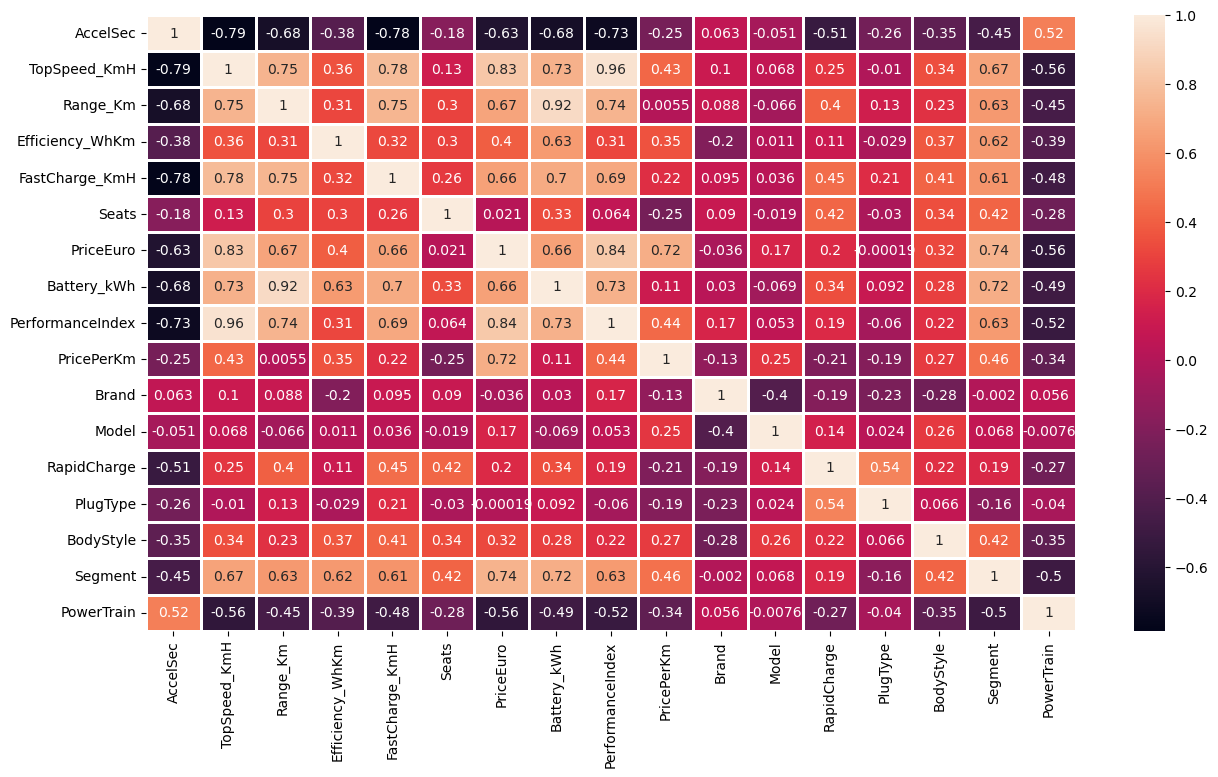

In [12]:
#Heatmap to show the correlation of the data
a = plt.figure(figsize=(15,8))
sns.heatmap(evision.corr(), linewidths=1,linecolor='white',annot=True)

In [13]:
# select relevant features for predicting range and efficiency

features = ['TopSpeed_KmH', 'PriceEuro', 'Segment', 'RapidCharge', 'Efficiency_WhKm', 'Seats', 'BodyStyle', 'PlugType', 'Brand']
target_range = 'Range_Km'
target_efficiency = 'Efficiency_WhKm'

In [15]:
#TARGETS FEATURES
target_range = 'Range_Km'
target_efficiency = 'Efficiency_WhKm'


# FEATURES

X = evision.drop([target_range, target_efficiency], axis=1)

y_range = evision[target_range]
y_efficiency = evision[target_efficiency]

# TRAIN-TEST SPLIT
X_train, X_test, y_train_range, y_test_range = train_test_split(
    X, y_range, test_size=0.2, random_state=42)

_, _, y_train_efficiency, y_test_efficiency = train_test_split(
    X, y_efficiency, test_size=0.2, random_state=42)


# RANGE MODEL 
rf_range = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_range.fit(X_train, y_train_range)

y_pred_range = rf_range.predict(X_test)


# EFFICIENCY MODEL
rf_efficiency = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_efficiency.fit(X_train, y_train_efficiency)

y_pred_efficiency = rf_efficiency.predict(X_test)

# EVALUATION OF EACH MODEL

# Range
mse_range = mean_squared_error(y_test_range, y_pred_range)
r2_range = r2_score(y_test_range, y_pred_range)

# Efficiency
mse_efficiency = mean_squared_error(y_test_efficiency, y_pred_efficiency)
r2_efficiency = r2_score(y_test_efficiency, y_pred_efficiency)

# Results
print(f'Range Model = MSE: {mse_range:.2f}, R²: {r2_range:.4f}')
print(f'Efficiency Model = MSE: {mse_efficiency:.2f}, R²: {r2_efficiency:.4f}')

Range Model = MSE: 3675.65, R²: 0.7233
Efficiency Model = MSE: 338.70, R²: 0.7032
